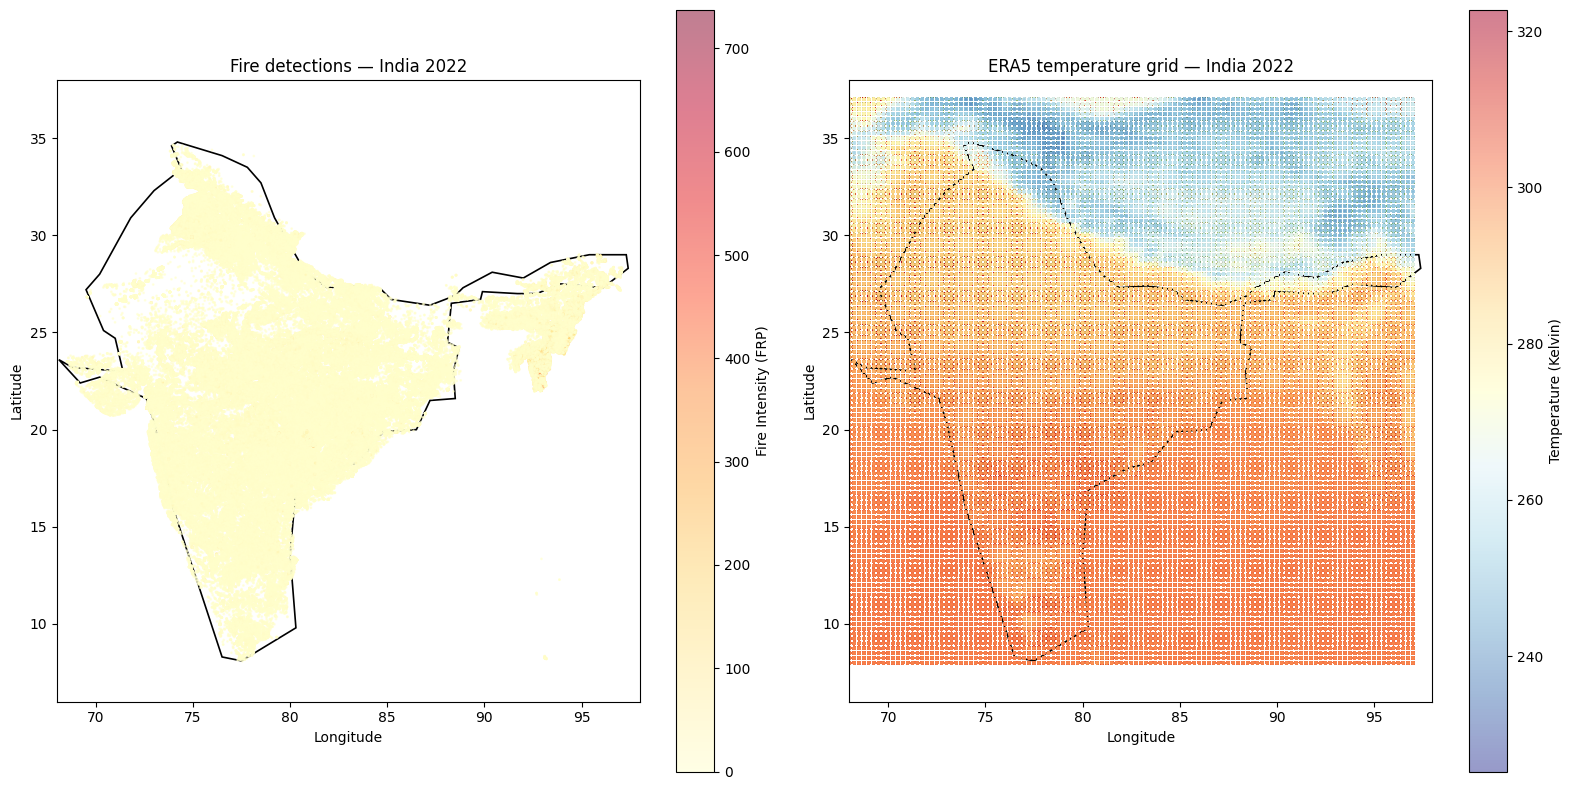

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from matplotlib.patches import Polygon as MplPolygon

df  = pd.read_csv('fire_archive_SV-C2_752168.csv')
dfd = pd.read_csv('era5_india_2022.csv')

india_coords = [
    (68.1,23.6),(69.2,22.4),(70.2,22.7),(72.6,21.6),(73.0,20.4),
    (74.0,15.9),(76.5,8.3),(77.5,8.1),(80.3,9.8),(80.0,13.6),
    (80.3,16.9),(82.3,18.0),(83.5,18.3),(84.8,19.9),(86.5,20.0),
    (87.2,21.5),(88.5,21.6),(88.4,23.0),(88.7,24.2),(88.1,24.5),
    (88.3,26.5),(89.8,26.7),(89.9,27.1),(91.7,27.0),(92.7,27.0),
    (93.9,27.5),(96.1,27.3),(97.4,28.3),(97.3,29.0),(95.4,29.0),
    (93.4,28.6),(92.0,27.8),(90.4,28.1),(88.9,27.3),(88.5,26.9),
    (87.2,26.4),(85.2,26.7),(84.7,27.2),(83.3,27.4),(81.9,27.3),
    (81.1,27.9),(80.5,28.6),(79.2,30.9),(78.5,32.7),(77.8,33.5),
    (76.5,34.1),(74.2,34.8),(73.9,34.6),(74.4,33.4),(73.0,32.3),
    (71.8,30.9),(70.2,28.0),(69.5,27.2),(70.4,25.1),(71.0,24.7),
    (71.4,23.0),(68.8,23.2),(68.1,23.6)
]

def draw_india(ax):
    poly = MplPolygon(india_coords, closed=True,
                      fill=False, edgecolor='black', linewidth=1.2)
    ax.add_patch(poly)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Fire side ---
draw_india(axes[0])
sc1 = axes[0].scatter(
    df['longitude'], df['latitude'],
    c=df['frp'], cmap='YlOrRd',
    s=1, alpha=0.5, zorder=2
)
plt.colorbar(sc1, ax=axes[0], label='Fire Intensity (FRP)')
axes[0].set_xlim(68, 98)
axes[0].set_ylim(6, 38)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Fire detections — India 2022')
axes[0].set_aspect('equal')

# --- ERA5 side ---
draw_india(axes[1])
sc2 = axes[1].scatter(
    dfd['longitude'], dfd['latitude'],
    c=dfd['t2m'], cmap='RdYlBu_r',
    s=2, alpha=0.5, zorder=2
)
plt.colorbar(sc2, ax=axes[1], label='Temperature (Kelvin)')
axes[1].set_xlim(68, 98)
axes[1].set_ylim(6, 38)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('ERA5 temperature grid — India 2022')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [2]:
import duckdb
import time

In [3]:
print("fire data")
print("Shape",df.shape)
print("Columns",df.columns.tolist())
print(df[['latitude','longitude','acq_date','frp','confidence']].head(3))

print("\nera5 data")
print("Shape",dfd.shape)
print("Columns",dfd.columns.tolist())
print(dfd[['latitude','longitude','t2m','u10','v10']].head(3))
 



fire data
Shape (591594, 15)
Columns ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type']
   latitude  longitude    acq_date   frp confidence
0  18.74842   84.27719  2022-01-01  4.50          n
1  17.60287   82.77369  2022-01-01  3.27          n
2  18.74585   84.27639  2022-01-01  2.85          n

era5 data
Shape (19985940, 14)
Columns ['valid_time', 'latitude', 'longitude', 't2m', 'swvl1', 'd2m', 'sp', 'u10', 'v10', 'number_x', 'expver_x', 'tp', 'number_y', 'expver_y']
   latitude  longitude        t2m       u10       v10
0      37.0      68.00  281.78943  1.339951 -0.894669
1      37.0      68.25  281.83630  1.788193  0.318222
2      37.0      68.50  282.14490  0.971786  1.520371


In [4]:
print("join key check")
print("fire longitude and latitude round up to 1dp")
print(df[['latitude','longitude']].head(3).round(1))
print("Fire date sample:", df['acq_date'].iloc[0])

print("ERA5 longitude and latitude round up to 1dp")
print(dfd[['latitude','longitude']].head(3).round(1))
print("ERA5 date sample:", dfd['valid_time'].iloc[0])


join key check
fire longitude and latitude round up to 1dp
   latitude  longitude
0      18.7       84.3
1      17.6       82.8
2      18.7       84.3
Fire date sample: 2022-01-01
ERA5 longitude and latitude round up to 1dp
   latitude  longitude
0      37.0       68.0
1      37.0       68.2
2      37.0       68.5
ERA5 date sample: 2022-01-01


In [5]:
print("joining spatiotemporally")
fire_file='fire_archive_SV-C2_752168.csv'
era5_file='era5_india_2022.csv'

start = time.time()

query = f"""
SELECT
    f.latitude,
    f.Longitude,
    f.acq_date as date,
    MAX(f.frp) as fire_intensity,
    MAX(f.confidence) as confidence,
    AVG(w.t2m) AS temp_2m,
    AVG(w.swvl1) AS soil_moisture,
    AVG(w.d2m) AS dewpoint_2m,
    AVG(w.sp) AS surface_pressure,
    AVG(w.u10) AS wind_u,
    AVG(w.v10) AS wind_v,
    SUM(w.tp) AS total_precipitation

    FROM read_csv_auto('{fire_file}') AS f
    JOIN read_csv_auto('{era5_file}') AS w
    ON ROUND(CAST(f.latitude AS DOUBLE), 1) = ROUND(CAST(w.latitude AS DOUBLE), 1)
    AND ROUND(CAST(f.longitude AS DOUBLE), 1) = ROUND(CAST(w.longitude AS DOUBLE), 1)
    AND cast(f.acq_date AS DATE) = cast(w.valid_time AS DATE)

    GROUP BY f.latitude, f.longitude, f.acq_date
    order by f.acq_date, f.latitude, f.longitude
"""
merged_df = duckdb.query(query).df()
print(f"Done in {round(time.time() - start, 2)} seconds")
merged_df.head(3)

joining spatiotemporally
Done in 2.24 seconds


,latitude,longitude,date,fire_intensity,confidence,temp_2m,soil_moisture,dewpoint_2m,surface_pressure,wind_u,wind_v,total_precipitation
0,15.77631,74.99257,2022-01-01,0.67,n,296.015470,0.202072,289.666185,94166.185,-3.386707,0.752167,4.768372e-07
1,15.95423,80.51012,2022-01-01,3.68,n,299.119480,0.127933,294.356130,101663.185,-2.824940,-0.610382,0.000000e+00
2,16.53568,75.98202,2022-01-01,1.37,n,297.017425,0.075721,289.948895,95386.685,-3.568592,0.927216,0.000000e+00


In [6]:
print("merged result")
print("Shape", merged_df.shape) # merging done correctly as expected satisfied (94417, 12)

print("date range:", merged_df['date'].min(), "to", merged_df['date'].max())
print("latitude range:", merged_df['latitude'].min(), "to", merged_df['latitude'].max())
print("longitude range:", merged_df['longitude'].min(), "to", merged_df['longitude'].max())

print("checking for NULL values : ")
print(merged_df.isnull().sum())
print("columns types ")
print(merged_df.dtypes)

merged result
Shape (94417, 12)
date range: 2022-01-01 00:00:00 to 2022-12-31 00:00:00
latitude range: 8.25338 to 34.33289
longitude range: 68.51766 to 97.0459
checking for NULL values : 
latitude               0
longitude              0
date                   0
fire_intensity         0
confidence             0
temp_2m                0
soil_moisture          0
dewpoint_2m            0
surface_pressure       0
wind_u                 0
wind_v                 0
total_precipitation    0
dtype: int64
columns types 
latitude                      float64
longitude                     float64
date                   datetime64[us]
fire_intensity                float64
confidence                        str
temp_2m                       float64
soil_moisture                 float64
dewpoint_2m                   float64
surface_pressure              float64
wind_u                        float64
wind_v                        float64
total_precipitation           float64
dtype: object


In [7]:
merged_df.to_csv('merged_file.csv', index=False)

confirm = pd.read_csv('merged_file.csv')
print(f"Saved : {confirm.shape}")
print(f"Cols  : {confirm.columns.tolist()}")


Saved : (94417, 12)
Cols  : ['latitude', 'longitude', 'date', 'fire_intensity', 'confidence', 'temp_2m', 'soil_moisture', 'dewpoint_2m', 'surface_pressure', 'wind_u', 'wind_v', 'total_precipitation']


In [9]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Shape: (591594, 15)
Columns: ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type']


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,18.74842,84.27719,335.45,0.49,0.65,2022-01-01,650,N,VIIRS,n,2,292.65,4.50,D,0
1,17.60287,82.77369,327.73,0.64,0.72,2022-01-01,650,N,VIIRS,n,2,293.86,3.27,D,0
2,18.74585,84.27639,338.01,0.49,0.65,2022-01-01,650,N,VIIRS,n,2,292.36,2.85,D,0
